In [1]:
import os, random, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything()

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
EPOCHS  = 80      # set to e.g. 3 for a quick dry run
print('device:', DEVICE)

ROOT    = Path('/kaggle/input/datasets/ahmedmosatafa63/flood-data/data')
IMG_DIR = ROOT / 'images'
LBL_DIR = ROOT / 'labels'

BAND_NAMES = ['Coastal aerosol', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2',
              'QA band', 'Merit DEM', 'Copernicus DEM', 'ESA WorldCover', 'Water occurrence']

device: cuda


In [2]:
image_files = sorted(IMG_DIR.glob('*.tif'),
                     key=lambda p: (0, int(p.stem)) if p.stem.isdigit() else (1, p.stem))
X_list, Y_list, names = [], [], []
for p in image_files:
    lp = LBL_DIR / p.name
    if not lp.exists():
        cand = list(LBL_DIR.glob(p.stem + '.*'))
        if not cand:
            print('missing label for', p.name); continue
        lp = cand[0]
    with rasterio.open(p) as s: X_list.append(s.read())
    with rasterio.open(lp) as s: Y_list.append(s.read(1))
    names.append(p.stem)

X = np.stack(X_list).astype(np.float32)          # (N, 12, 128, 128)
Y_raw = np.stack(Y_list)
Y = (Y_raw > 0).astype(np.float32)               # (N, 128, 128)
del X_list, Y_list
N = len(X)
print('X:', X.shape, '| Y:', Y.shape)
print('label raw unique values:', np.unique(Y_raw))

X: (306, 12, 128, 128) | Y: (306, 128, 128)
label raw unique values: [0 1]


NaN in X: 0 | Inf in X: 0


,band,min,max,mean,std,n_unique(first 50 imgs)
0,Coastal aerosol,-1393.0,6568.0,396.470001,270.070007,3071
1,Blue,-1169.0,9659.0,494.619995,325.980011,4833
2,Green,-722.0,11368.0,822.320007,418.119995,5266
3,Red,-684.0,12041.0,973.679993,586.700012,5614
4,NIR,-412.0,15841.0,2090.110107,1055.979980,5900
5,SWIR1,-335.0,15252.0,1964.050049,1191.420044,5582
6,SWIR2,-258.0,14647.0,1351.270020,961.760010,4525
7,QA band,64.0,255.0,102.739998,48.799999,36
8,Merit DEM,-9999.0,4245.0,141.800003,1364.979980,2774
9,Copernicus DEM,8.0,4287.0,300.739990,496.040009,2754


Overall water pixel ratio: 0.260
images with no water: 45 | fully water: 3


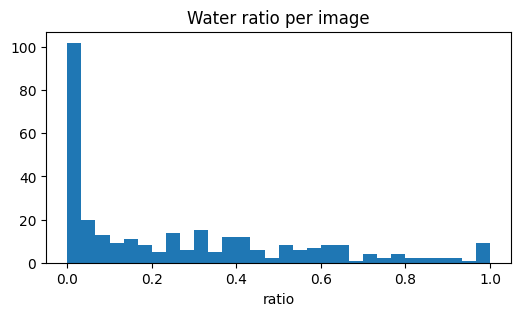

In [3]:
print('NaN in X:', int(np.isnan(X).sum()), '| Inf in X:', int(np.isinf(X).sum()))
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

stats = pd.DataFrame({
    'band': BAND_NAMES,
    'min':  X.min((0, 2, 3)), 'max': X.max((0, 2, 3)),
    'mean': X.mean((0, 2, 3)), 'std': X.std((0, 2, 3)),
    'n_unique(first 50 imgs)': [len(np.unique(X[:50, c])) for c in range(12)],
})
display(stats.round(2))

ratio = Y.mean((1, 2))
print(f'Overall water pixel ratio: {Y.mean():.3f}')
print('images with no water:', int((ratio == 0).sum()), '| fully water:', int((ratio == 1).sum()))
plt.figure(figsize=(6, 3)); plt.hist(ratio, bins=30); plt.title('Water ratio per image'); plt.xlabel('ratio'); plt.show()

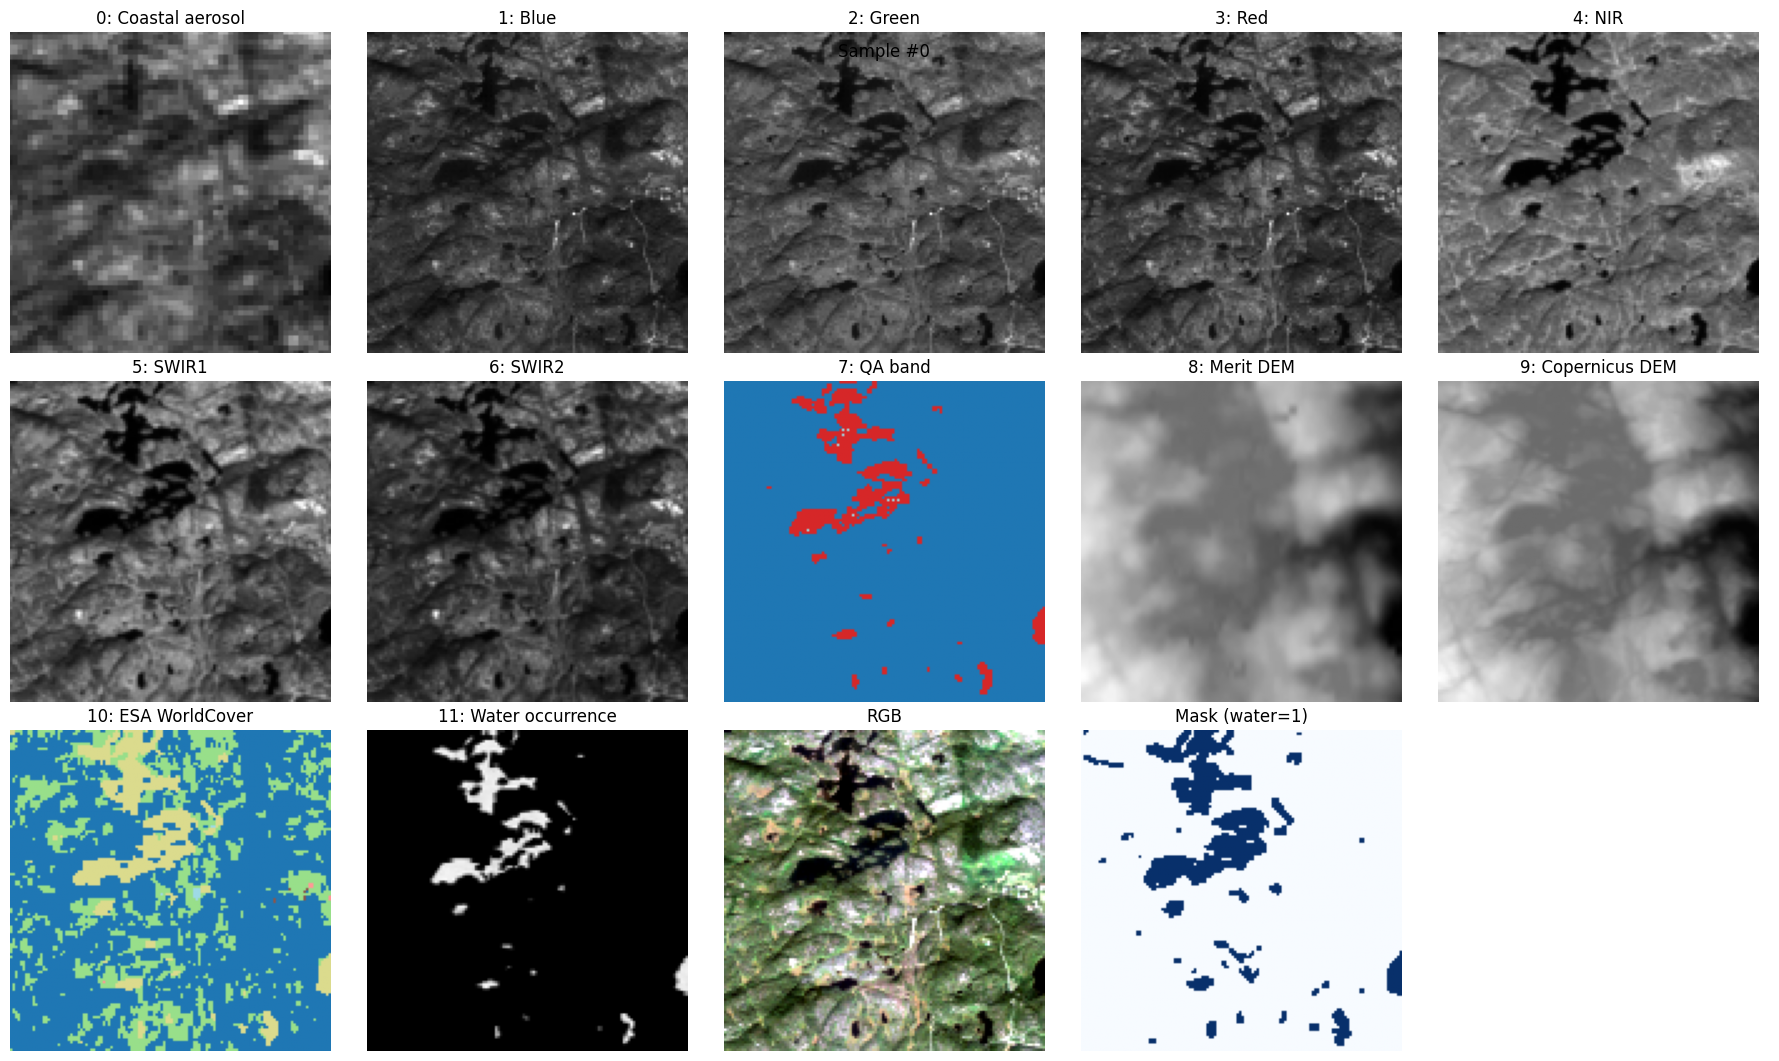

In [4]:
def rgb(img, bands=(3, 2, 1)):          # Red, Green, Blue
    out = np.zeros((*img.shape[1:], 3), np.float32)
    for k, b in enumerate(bands):
        v = img[b]; lo, hi = np.percentile(v, 2), np.percentile(v, 98)
        out[..., k] = np.clip((v - lo) / (hi - lo + 1e-6), 0, 1)
    return out

cand = np.where((ratio > 0.1) & (ratio < 0.6))[0]
s = int(cand[0]) if len(cand) else int(ratio.argmax())

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
for c in range(12):
    ax = axes.flat[c]
    ax.imshow(X[s, c], cmap='tab20' if c in (7, 10) else 'gray')
    ax.set_title(f'{c}: {BAND_NAMES[c]}'); ax.axis('off')
axes.flat[12].imshow(rgb(X[s])); axes.flat[12].set_title('RGB'); axes.flat[12].axis('off')
axes.flat[13].imshow(Y[s], cmap='Blues'); axes.flat[13].set_title('Mask (water=1)'); axes.flat[13].axis('off')
axes.flat[14].axis('off')
plt.suptitle(f'Sample #{s}', y=0.93); plt.tight_layout(); plt.show()

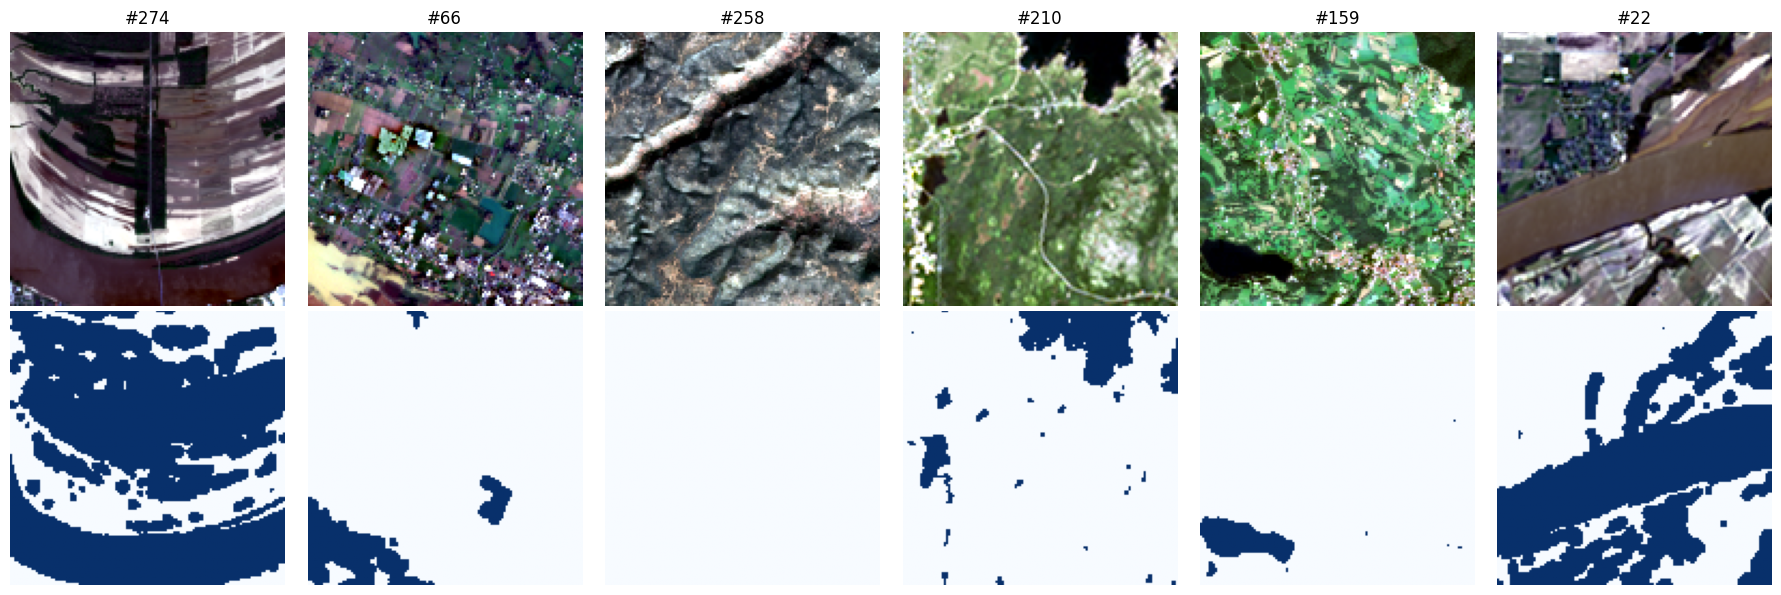

In [5]:
sel = np.random.RandomState(0).choice(N, 6, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for j, i in enumerate(sel):
    axes[0, j].imshow(rgb(X[i])); axes[0, j].set_title(f'#{i}'); axes[0, j].axis('off')
    axes[1, j].imshow(Y[i], cmap='Blues'); axes[1, j].axis('off')
axes[0, 0].set_ylabel('RGB'); plt.tight_layout(); plt.show()

,band,water_mean,bg_mean,water_std,bg_std,separation
0,Coastal aerosol,363.089996,408.179993,195.070007,290.940002,0.18
1,Blue,479.320007,499.989990,252.600006,347.920013,0.07
2,Green,826.770020,820.760010,350.010010,439.519989,0.02
3,Red,950.919983,981.659973,469.190002,622.510010,0.06
4,NIR,962.090027,2485.929932,840.770020,809.429993,1.85
5,SWIR1,817.940002,2366.219971,1022.919983,963.190002,1.56
6,SWIR2,596.830017,1616.010010,773.200012,877.479980,1.23
7,QA band,125.750000,94.660004,52.980000,44.509998,0.64
8,Merit DEM,-441.239990,346.390015,2425.139893,540.429993,0.45
9,Copernicus DEM,155.029999,351.869995,326.839996,533.710022,0.44


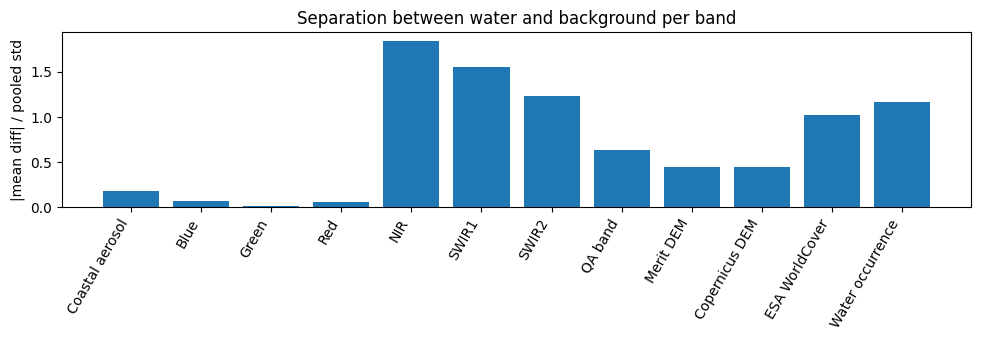

In [6]:
w = Y.astype(bool)
rows = []
for c in range(12):
    ch = X[:, c]
    mw, mb = ch[w].mean(), ch[~w].mean()
    sw, sb = ch[w].std(), ch[~w].std()
    rows.append(dict(band=BAND_NAMES[c], water_mean=mw, bg_mean=mb, water_std=sw, bg_std=sb,
                     separation=abs(mw - mb) / (np.sqrt((sw**2 + sb**2) / 2) + 1e-9)))
sep = pd.DataFrame(rows)
display(sep.round(2))
plt.figure(figsize=(10, 3.5)); plt.bar(sep.band, sep.separation); plt.xticks(rotation=60, ha='right')
plt.ylabel('|mean diff| / pooled std'); plt.title('Separation between water and background per band')
plt.tight_layout(); plt.show()

In [7]:
perm = np.random.RandomState(SEED).permutation(N)
n_tr, n_va = int(0.70 * N), int(0.15 * N)
tr_idx, va_idx, te_idx = perm[:n_tr], perm[n_tr:n_tr + n_va], perm[n_tr + n_va:]
print('train / val / test =', len(tr_idx), len(va_idx), len(te_idx))
for n_, ix in [('train', tr_idx), ('val', va_idx), ('test', te_idx)]:
    print(f'{n_:5s} water ratio: {Y[ix].mean():.3f}')

train / val / test = 214 45 47
train water ratio: 0.278
val   water ratio: 0.208
test  water ratio: 0.228


X_all: (306, 16, 128, 128)


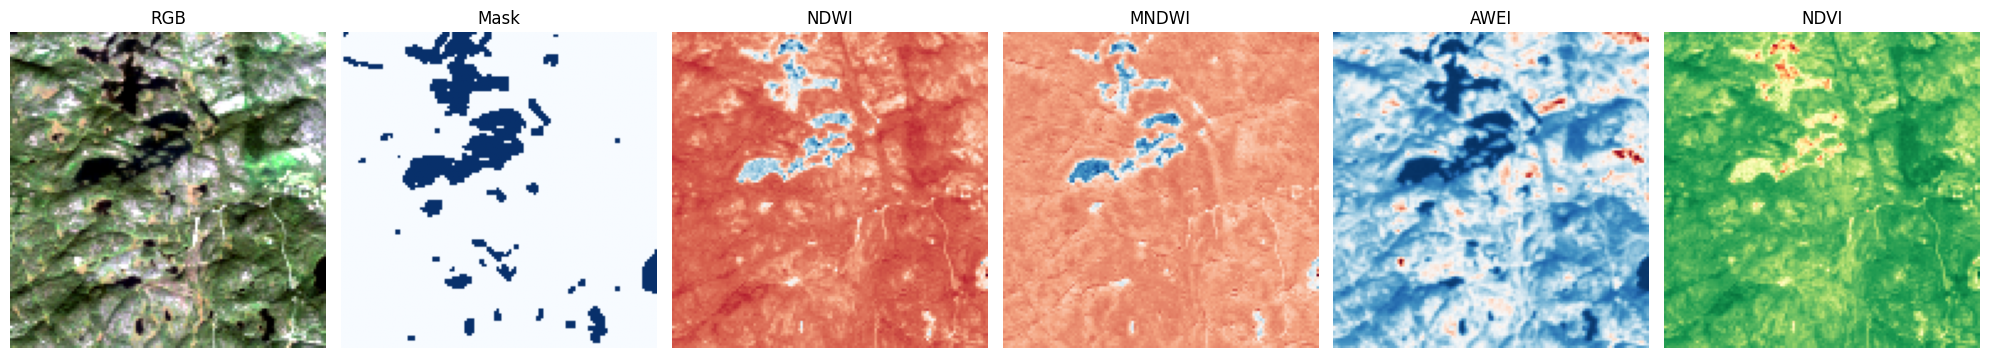

In [8]:
def compute_indices(x, eps=1e-6):
    # x: raw reflectance (N,12,H,W)
    G, R, NIR, S1, S2 = x[:, 2], x[:, 3], x[:, 4], x[:, 5], x[:, 6]
    ndwi  = (G - NIR) / (G + NIR + eps)       # McFeeters
    mndwi = (G - S1)  / (G + S1  + eps)       # Xu (better in urban areas)
    ndvi  = (NIR - R) / (NIR + R + eps)       # vegetation (opposite of water)
    awei  = 4 * (G - S1) - (0.25 * NIR + 2.75 * S2)   # AWEI (no shadow)
    ndwi, mndwi, ndvi = [np.clip(a, -1, 1) for a in (ndwi, mndwi, ndvi)]
    return np.stack([ndwi, mndwi, ndvi, awei], 1).astype(np.float32)

IDX = compute_indices(X)                                  # computed from raw values, before normalization
INDEX_NAMES = ['NDWI', 'MNDWI', 'NDVI', 'AWEI']
ALL_NAMES = BAND_NAMES + INDEX_NAMES
X_all = np.concatenate([X, IDX], 1)                       # (N, 16, 128, 128)
print('X_all:', X_all.shape)

fig, axes = plt.subplots(1, 6, figsize=(20, 3.5))
for ax, im, t, cm in zip(axes, [rgb(X[s]), Y[s], IDX[s, 0], IDX[s, 1], IDX[s, 3], IDX[s, 2]],
                         ['RGB', 'Mask', 'NDWI', 'MNDWI', 'AWEI', 'NDVI'],
                         [None, 'Blues', 'RdBu', 'RdBu', 'RdBu', 'RdYlGn']):
    ax.imshow(im, cmap=cm); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

In [9]:
def prf(tp, fp, fn, eps=1e-7):
    p = tp / (tp + fp + eps); r = tp / (tp + fn + eps)
    return dict(precision=p, recall=r, f1=2 * p * r / (p + r + eps), iou=tp / (tp + fp + fn + eps))

# non-deep-learning baseline: threshold the index directly (on the test set)
y_te = Y[te_idx] > 0.5
rows = []
for nm, k in [('NDWI > 0', 0), ('MNDWI > 0', 1), ('AWEI > 0', 3)]:
    pr = IDX[te_idx, k] > 0
    rows.append(dict(method=nm, **prf((pr & y_te).sum(), (pr & ~y_te).sum(), (~pr & y_te).sum())))
display(pd.DataFrame(rows).round(4))

,method,precision,recall,f1,iou
0,NDWI > 0,0.9298,0.5632,0.7015,0.5402
1,MNDWI > 0,0.9126,0.5764,0.7066,0.5463
2,AWEI > 0,0.9178,0.5094,0.6552,0.4872


In [10]:
class ChannelNormalizer:
    def __init__(self, q_low, q_high): self.q_low, self.q_high = q_low, q_high
    def fit(self, x):
        C = x.shape[1]; self.lo = np.zeros(C, np.float32); self.hi = np.zeros(C, np.float32)
        for c in range(C):
            v = x[:, c].ravel()
            self.lo[c] = v.min() if self.q_low[c] == 0 else np.percentile(v, self.q_low[c])
            self.hi[c] = v.max() if self.q_high[c] == 100 else np.percentile(v, self.q_high[c])
        return self
    def transform(self, x):
        lo = self.lo.reshape(1, -1, 1, 1); hi = self.hi.reshape(1, -1, 1, 1)
        return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1).astype(np.float32)

q_low  = [0] * 12 + [1] * 4
q_high = [100] * 12 + [99] * 4
norm = ChannelNormalizer(q_low, q_high).fit(X_all[tr_idx])     # train only!
X_norm = norm.transform(X_all)                                 # (N, 16, H, W) in [0,1]
print(pd.DataFrame({'channel': ALL_NAMES, 'lo': norm.lo, 'hi': norm.hi}).round(3))

             channel         lo         hi
0    Coastal aerosol  -1393.000   6390.000
1               Blue  -1169.000   9659.000
2              Green   -722.000  11368.000
3                Red   -684.000  12041.000
4                NIR   -412.000  15841.000
5              SWIR1   -335.000  15252.000
6              SWIR2   -251.000  14647.000
7            QA band     64.000    255.000
8          Merit DEM  -9999.000   4245.000
9     Copernicus DEM      8.000   4287.000
10    ESA WorldCover     10.000    100.000
11  Water occurrence      0.000    111.000
12              NDWI     -0.810      1.000
13             MNDWI     -0.667      0.988
14              NDVI     -0.638      0.903
15              AWEI -23526.500   4092.750


In [11]:
class FloodDS(Dataset):
    def __init__(self, X, Y, idx, chans, augment=False):
        self.x = torch.from_numpy(np.ascontiguousarray(X[idx][:, chans]))
        self.y = torch.from_numpy(Y[idx]).unsqueeze(1)
        self.augment = augment
    def __len__(self): return len(self.x)
    def __getitem__(self, i):
        x, y = self.x[i], self.y[i]
        if self.augment:
            if random.random() < 0.5: x, y = x.flip(-1), y.flip(-1)
            if random.random() < 0.5: x, y = x.flip(-2), y.flip(-2)
            k = random.randint(0, 3)
            if k: x, y = torch.rot90(x, k, (1, 2)), torch.rot90(y, k, (1, 2))
        return x.contiguous(), y.contiguous()


class DoubleConv(nn.Module):
    def __init__(self, i, o):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(True),
            nn.Conv2d(o, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(True))
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_ch, base=32):
        super().__init__()
        f = [base, base * 2, base * 4, base * 8, base * 16]
        self.e1, self.e2 = DoubleConv(in_ch, f[0]), DoubleConv(f[0], f[1])
        self.e3, self.e4 = DoubleConv(f[1], f[2]), DoubleConv(f[2], f[3])
        self.bott = DoubleConv(f[3], f[4])
        self.pool = nn.MaxPool2d(2)
        self.up4 = nn.ConvTranspose2d(f[4], f[3], 2, 2); self.d4 = DoubleConv(f[4], f[3])
        self.up3 = nn.ConvTranspose2d(f[3], f[2], 2, 2); self.d3 = DoubleConv(f[3], f[2])
        self.up2 = nn.ConvTranspose2d(f[2], f[1], 2, 2); self.d2 = DoubleConv(f[2], f[1])
        self.up1 = nn.ConvTranspose2d(f[1], f[0], 2, 2); self.d1 = DoubleConv(f[1], f[0])
        self.out = nn.Conv2d(f[0], 1, 1)
    def forward(self, x):
        e1 = self.e1(x); e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2)); e4 = self.e4(self.pool(e3))
        b = self.bott(self.pool(e4))
        d4 = self.d4(torch.cat([self.up4(b), e4], 1))
        d3 = self.d3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.d2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.d1(torch.cat([self.up1(d2), e1], 1))
        return self.out(d1)       # logits


def dice_loss(logits, y, eps=1.0):
    p = torch.sigmoid(logits)
    inter = (p * y).sum((1, 2, 3)); den = p.sum((1, 2, 3)) + y.sum((1, 2, 3))
    return (1 - (2 * inter + eps) / (den + eps)).mean()

bce = nn.BCEWithLogitsLoss()
def criterion(logits, y): return bce(logits, y) + dice_loss(logits, y)


@torch.no_grad()
def evaluate(model, loader, thr=0.5):
    model.eval(); tp = fp = fn = 0.0; ls = 0.0; n = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        lg = model(x); ls += criterion(lg, y).item() * len(x); n += len(x)
        p = (torch.sigmoid(lg) > thr).float()
        tp += (p * y).sum().item(); fp += (p * (1 - y)).sum().item(); fn += ((1 - p) * y).sum().item()
    out = prf(tp, fp, fn); out['loss'] = ls / n
    return out

@torch.no_grad()
def predict_probs(model, x, bs=32):
    model.eval(); outs = []
    for i in range(0, len(x), bs):
        outs.append(torch.sigmoid(model(x[i:i + bs].to(DEVICE))).cpu())
    return torch.cat(outs)

def f1_from_probs(p, y, thr):
    b = (p > thr).float()
    return prf((b * y).sum().item(), (b * (1 - y)).sum().item(), ((1 - b) * y).sum().item())

print('params (12 ch):', sum(p.numel() for p in UNet(12).parameters()) / 1e6, 'M')

params (12 ch): 7.765633 M


In [12]:
def train_model(chans, epochs=EPOCHS, lr=1e-3, bs=16, patience=12, name=''):
    seed_everything()
    tr = DataLoader(FloodDS(X_norm, Y, tr_idx, chans, True), batch_size=bs, shuffle=True, drop_last=True)
    va = DataLoader(FloodDS(X_norm, Y, va_idx, chans), batch_size=bs)
    model = UNet(len(chans)).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=4)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
    hist, best, best_state, bad = [], -1, None, 0
    for ep in range(1, epochs + 1):
        model.train(); tl = 0.0
        for x, y in tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type='cuda', enabled=USE_AMP):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tl += loss.item() * len(x)
        v = evaluate(model, va); sched.step(v['iou'])
        hist.append(dict(epoch=ep, train_loss=tl / (len(tr) * bs), val_loss=v['loss'], f1=v['f1'], iou=v['iou']))
        if v['iou'] > best:
            best, bad = v['iou'], 0
            best_state = {k: t.detach().clone() for k, t in model.state_dict().items()}
        else:
            bad += 1
        if ep % 5 == 0 or ep == 1:
            print(f'[{name}] ep {ep:3d} | train {hist[-1]["train_loss"]:.4f} | val loss {v["loss"]:.4f} | val F1 {v["f1"]:.4f} | val IoU {v["iou"]:.4f}')
        if bad >= patience:
            print(f'[{name}] early stop at epoch {ep}'); break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist)

def tune_threshold(model, chans):
    pv = predict_probs(model, torch.from_numpy(np.ascontiguousarray(X_norm[va_idx][:, chans])))
    yv = torch.from_numpy(Y[va_idx]).unsqueeze(1)
    best_t, best_f = 0.5, -1
    for t in np.arange(0.1, 0.91, 0.05):
        f = f1_from_probs(pv, yv, t)['f1']
        if f > best_f: best_t, best_f = float(t), f
    return best_t

In [13]:
RAW, IDXS = list(range(12)), [12, 13, 14, 15]
EXPERIMENTS = {
    'E1_baseline_12ch':             RAW,
    'E2_12ch_+_indices':            RAW + IDXS,
    'E3_spectral7_+_indices':       list(range(7)) + IDXS,
    'E4_spectral7_only':            list(range(7)),
    'E5_no_water_occurrence':       list(range(11)) + IDXS,
    'E6_no_DEM_no_occurrence':      list(range(8)) + [10] + IDXS,
}
for k, v in EXPERIMENTS.items(): print(k, '->', len(v), 'channels')

E1_baseline_12ch -> 12 channels
E2_12ch_+_indices -> 16 channels
E3_spectral7_+_indices -> 11 channels
E4_spectral7_only -> 7 channels
E5_no_water_occurrence -> 15 channels
E6_no_DEM_no_occurrence -> 13 channels


In [14]:
results, models, histories, thresholds = [], {}, {}, {}
for name, chans in EXPERIMENTS.items():
    t0 = time.time()
    model, hist = train_model(chans, name=name)
    thr = tune_threshold(model, chans)
    te = DataLoader(FloodDS(X_norm, Y, te_idx, chans), batch_size=16)
    r05, rt = evaluate(model, te, 0.5), evaluate(model, te, thr)
    results.append(dict(experiment=name, n_channels=len(chans), thr=thr,
                        precision=rt['precision'], recall=rt['recall'], f1=rt['f1'], iou=rt['iou'],
                        f1_at_0_5=r05['f1'], iou_at_0_5=r05['iou'],
                        best_val_iou=hist['iou'].max(), epochs_run=len(hist)))
    models[name], histories[name], thresholds[name] = model, hist, thr
    print(f'>>> {name}: test F1={rt["f1"]:.4f} IoU={rt["iou"]:.4f} (thr={thr:.2f}) | {time.time()-t0:.0f}s\n')

[E1_baseline_12ch] ep   1 | train 1.1046 | val loss 1.3200 | val F1 0.0000 | val IoU 0.0000
[E1_baseline_12ch] ep   5 | train 0.8491 | val loss 1.0017 | val F1 0.7669 | val IoU 0.6219
[E1_baseline_12ch] ep  10 | train 0.7736 | val loss 0.8253 | val F1 0.7803 | val IoU 0.6398
[E1_baseline_12ch] ep  15 | train 0.7697 | val loss 0.8404 | val F1 0.7720 | val IoU 0.6287
[E1_baseline_12ch] ep  20 | train 0.7226 | val loss 0.7094 | val F1 0.8137 | val IoU 0.6859
[E1_baseline_12ch] ep  25 | train 0.6977 | val loss 0.8051 | val F1 0.7944 | val IoU 0.6589
[E1_baseline_12ch] ep  30 | train 0.6716 | val loss 0.6931 | val F1 0.8192 | val IoU 0.6937
[E1_baseline_12ch] ep  35 | train 0.6585 | val loss 0.6815 | val F1 0.8157 | val IoU 0.6887
[E1_baseline_12ch] ep  40 | train 0.6787 | val loss 0.6805 | val F1 0.8219 | val IoU 0.6977
[E1_baseline_12ch] ep  45 | train 0.6567 | val loss 0.6906 | val F1 0.8150 | val IoU 0.6878
[E1_baseline_12ch] ep  50 | train 0.6473 | val loss 0.6754 | val F1 0.8194 | val

,experiment,n_channels,thr,precision,recall,f1,iou,f1_at_0_5,iou_at_0_5,best_val_iou,epochs_run
0,E1_baseline_12ch,12,0.55,0.8316,0.7878,0.8091,0.6794,0.8102,0.6809,0.6978,64
1,E2_12ch_+_indices,16,0.50,0.8395,0.7682,0.8022,0.6698,0.8022,0.6698,0.7078,40
2,E3_spectral7_+_indices,11,0.50,0.8323,0.7497,0.7889,0.6513,0.7889,0.6513,0.6970,39
3,E4_spectral7_only,7,0.50,0.8368,0.7854,0.8103,0.6811,0.8103,0.6811,0.6951,48
4,E5_no_water_occurrence,15,0.50,0.8124,0.7637,0.7873,0.6493,0.7873,0.6493,0.7082,41
5,E6_no_DEM_no_occurrence,13,0.50,0.8597,0.7511,0.8017,0.6691,0.8017,0.6691,0.7049,31


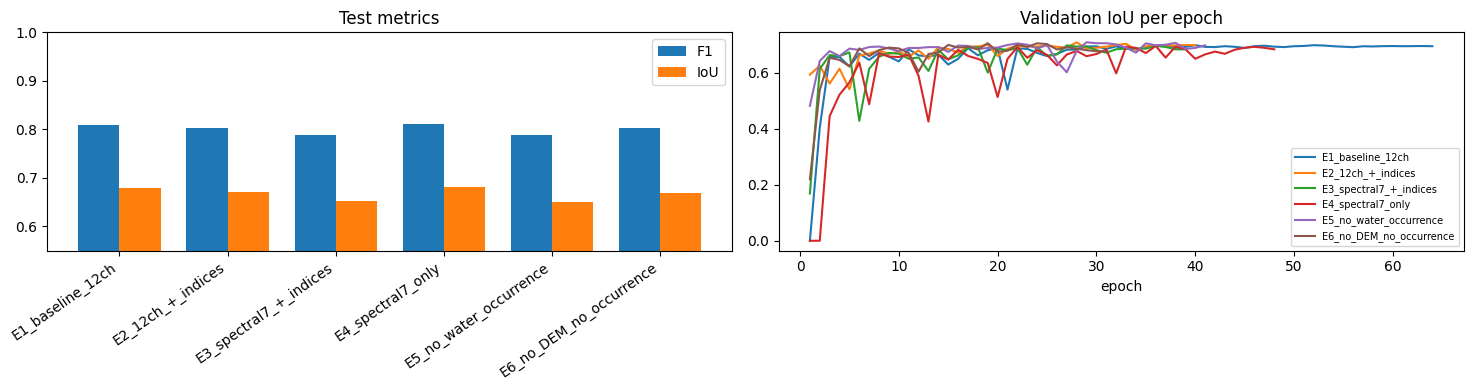

In [15]:
res = pd.DataFrame(results)
display(res.round(4))

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
x = np.arange(len(res)); wd = 0.38
ax[0].bar(x - wd/2, res.f1, wd, label='F1'); ax[0].bar(x + wd/2, res.iou, wd, label='IoU')
ax[0].set_xticks(x); ax[0].set_xticklabels(res.experiment, rotation=35, ha='right')
ax[0].set_ylim(max(0, res[['f1', 'iou']].min().min() - 0.1), 1); ax[0].legend(); ax[0].set_title('Test metrics')
for n_, h in histories.items(): ax[1].plot(h.epoch, h.iou, label=n_)
ax[1].set_title('Validation IoU per epoch'); ax[1].set_xlabel('epoch'); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

best experiment (by val IoU): E5_no_water_occurrence | threshold: 0.5000000000000001


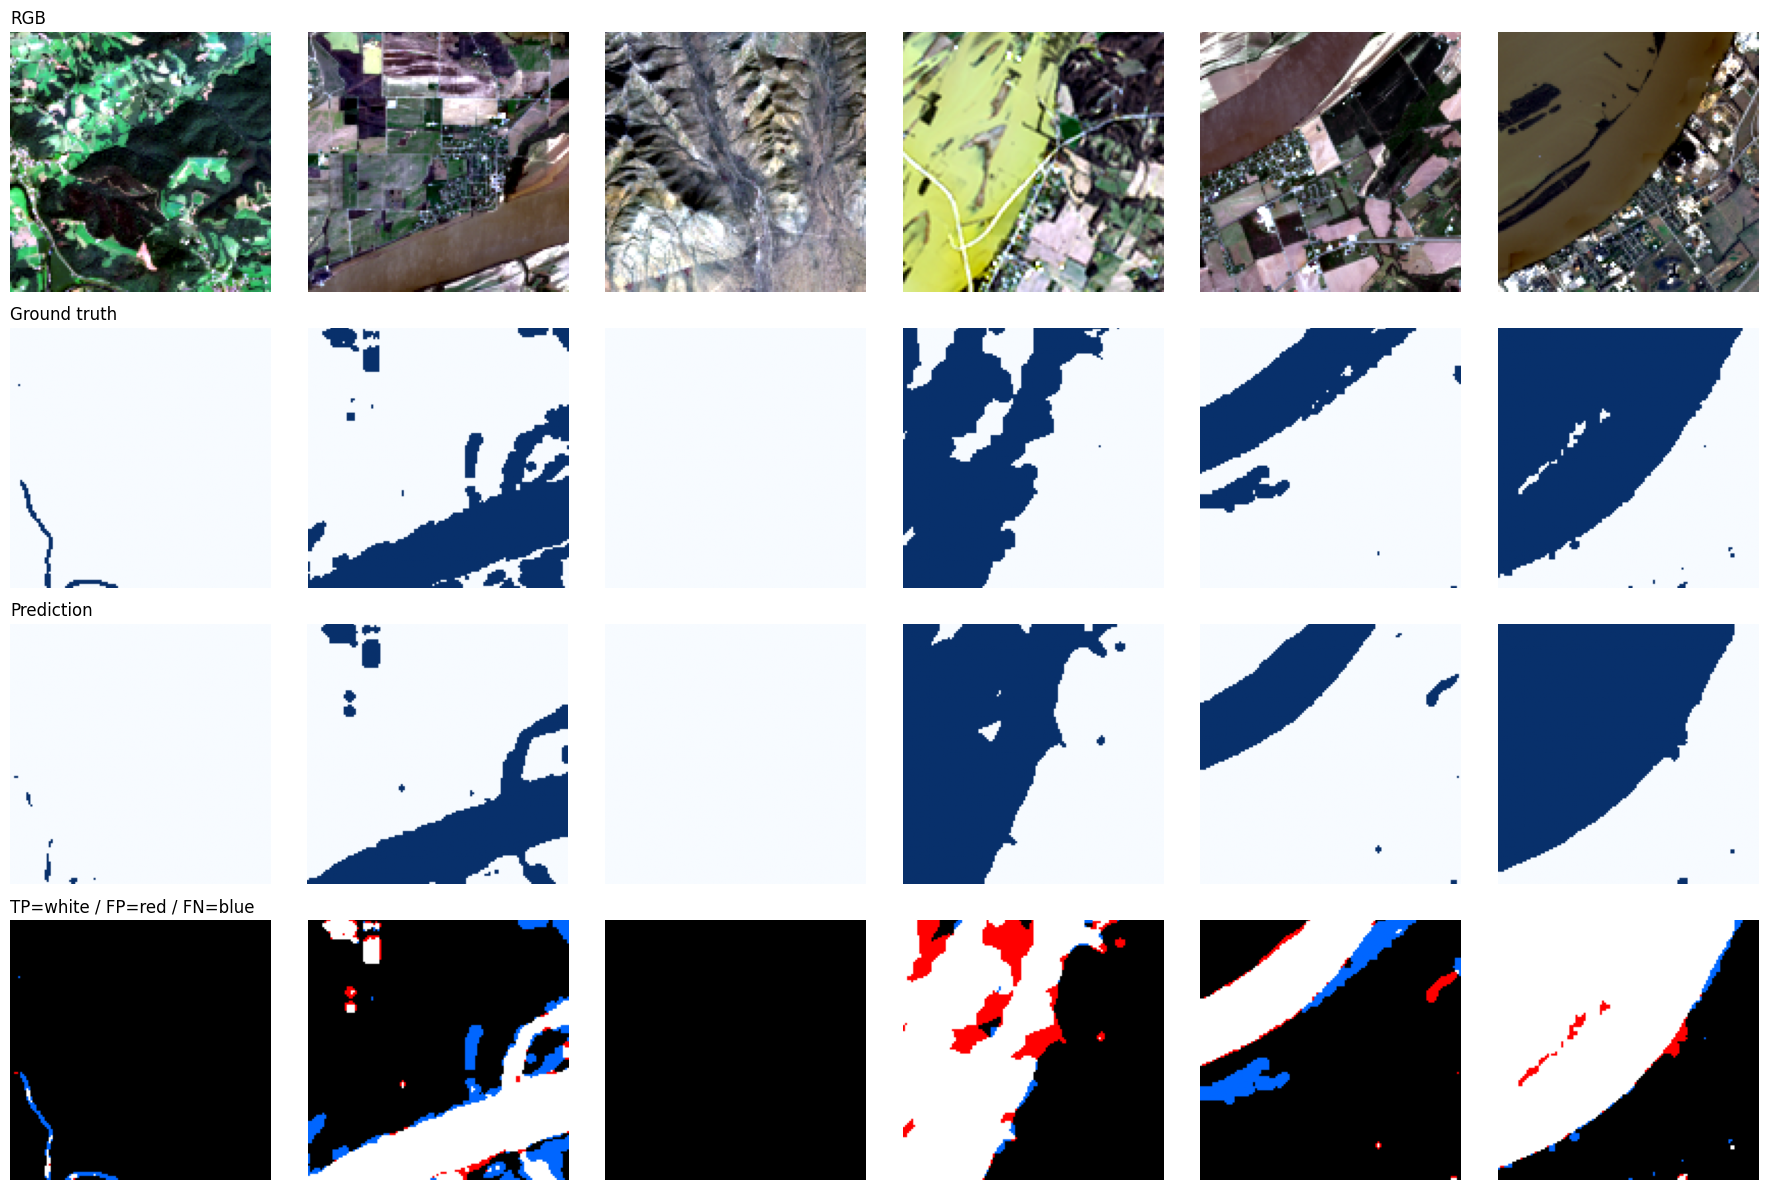

In [16]:
best_name = res.loc[res.best_val_iou.idxmax(), 'experiment']      # selected by validation, not test
chans, model, thr = EXPERIMENTS[best_name], models[best_name], thresholds[best_name]
print('best experiment (by val IoU):', best_name, '| threshold:', thr)

Xt = torch.from_numpy(np.ascontiguousarray(X_norm[te_idx][:, chans]))
yt = torch.from_numpy(Y[te_idx]).unsqueeze(1)
pt = predict_probs(model, Xt)

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
for j in range(6):
    i = te_idx[j]; pm = (pt[j, 0] > thr).numpy(); gt = Y[i]
    err = np.zeros((*gt.shape, 3)); err[(pm == 1) & (gt == 1)] = (1, 1, 1)
    err[(pm == 1) & (gt == 0)] = (1, 0, 0); err[(pm == 0) & (gt == 1)] = (0, 0.4, 1)
    for r, (im, cm) in enumerate([(rgb(X[i]), None), (gt, 'Blues'), (pm, 'Blues'), (err, None)]):
        axes[r, j].imshow(im, cmap=cm); axes[r, j].axis('off')
for r, t in enumerate(['RGB', 'Ground truth', 'Prediction', 'TP=white / FP=red / FN=blue']): axes[r, 0].set_title(t, loc='left')
plt.tight_layout(); plt.show()

,channel,F1_drop
11,NDWI,0.2586
12,MNDWI,0.2559
5,SWIR1,0.0580
2,Green,0.0355
1,Blue,0.0323
10,ESA WorldCover,0.0217
14,AWEI,0.0171
4,NIR,0.0072
13,NDVI,0.0030
6,SWIR2,0.0017


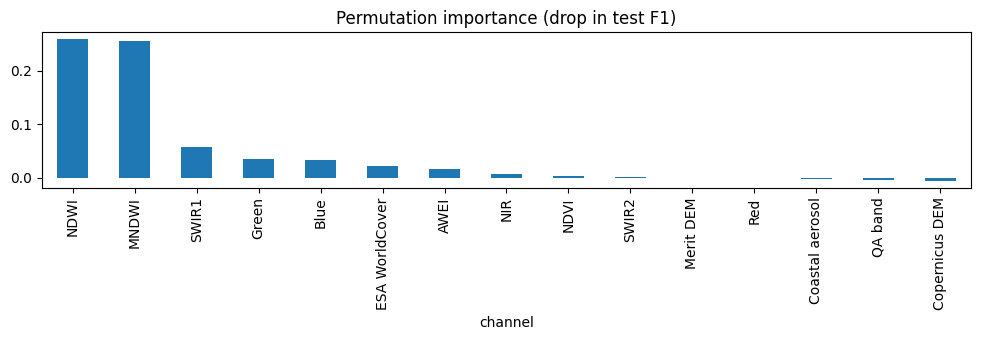

In [17]:
# Permutation importance: shuffle one channel across images and measure the drop in F1
base_f1 = f1_from_probs(pt, yt, thr)['f1']
g = torch.Generator().manual_seed(SEED); imp = []
for j, c in enumerate(chans):
    xp = Xt.clone(); xp[:, j] = Xt[torch.randperm(len(Xt), generator=g), j]
    imp.append(base_f1 - f1_from_probs(predict_probs(model, xp), yt, thr)['f1'])
imp = pd.DataFrame({'channel': [ALL_NAMES[c] for c in chans], 'F1_drop': imp}).sort_values('F1_drop', ascending=False)
display(imp.round(4))
imp.plot.bar(x='channel', y='F1_drop', figsize=(10, 3.5), legend=False, title='Permutation importance (drop in test F1)')
plt.tight_layout(); plt.show()

In [18]:
OUT = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
res.to_csv(OUT / 'ablation_results.csv', index=False)
torch.save({'state_dict': model.state_dict(), 'channels': chans, 'thr': thr,
            'norm_lo': norm.lo, 'norm_hi': norm.hi}, OUT / 'best_unet.pt')
print('saved to', OUT)

saved to /kaggle/working


In [19]:
!pip -q install segmentation-models-pytorch
import segmentation_models_pytorch as smp
print('smp', smp.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.9 MB/s eta 0:00:00:00:01
smp 0.5.0


In [20]:
class SMPWrap(nn.Module):
    """Wrapper that applies a simple standardization to the inputs (X_norm is in [0, 1])
    and then runs the smp model."""
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        return self.m((x - 0.5) / 0.25)

def adapt_first_conv(model, chans, mode='mean'):
    """
    Replace the first 3-channel Conv2d of the encoder with a conv that takes len(chans) channels.
    mode='mean': average the pretrained RGB filters, repeat across all channels, rescale by 3/in_ch
    mode='zero': copy the pretrained RGB filters onto the Red/Green/Blue bands, zero for all other bands
    """
    in_ch = len(chans)
    for name, m in model.encoder.named_modules():
        if isinstance(m, nn.Conv2d) and m.in_channels == 3:
            break
    else:
        raise RuntimeError('first conv not found')
    w = m.weight.data                                   # (out, 3, k, k)
    new = nn.Conv2d(in_ch, m.out_channels, m.kernel_size, m.stride, m.padding,
                    bias=m.bias is not None)
    with torch.no_grad():
        if mode == 'mean':
            new.weight.copy_(w.mean(1, keepdim=True).repeat(1, in_ch, 1, 1) * 3 / in_ch)
        elif mode == 'zero':
            new.weight.zero_()
            # ImageNet filter order is R, G, B -> dataset bands: Red=3, Green=2, Blue=1
            for k, band in enumerate([3, 2, 1]):
                if band in chans:
                    new.weight[:, chans.index(band)] = w[:, k]
        else:
            raise ValueError(mode)
        if m.bias is not None:
            new.bias.copy_(m.bias)
    parts = name.split('.')
    parent = model.encoder
    for p in parts[:-1]:
        parent = getattr(parent, p)
    setattr(parent, parts[-1], new)
    if hasattr(model.encoder, '_in_channels'):
        model.encoder._in_channels = in_ch
    return model

def build_model(arch='Unet', encoder='resnet34', chans=RAW, init='mean', pretrained=True):
    cls = {'Unet': smp.Unet, 'DeepLabV3Plus': smp.DeepLabV3Plus}[arch]
    m = cls(encoder_name=encoder,
            encoder_weights='imagenet' if pretrained else None,
            in_channels=3, classes=1)
    m = adapt_first_conv(m, chans, init)
    return SMPWrap(m)

# Sanity check: forward pass with 12-channel input
for arch in ['Unet', 'DeepLabV3Plus']:
    mdl = build_model(arch, 'resnet34', RAW, 'mean').to(DEVICE)
    out = mdl(torch.randn(2, 12, 128, 128).to(DEVICE))
    print(arch, 'out:', tuple(out.shape), '| params: %.2fM' % (sum(p.numel() for p in mdl.parameters()) / 1e6))

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Unet out: (2, 1, 128, 128) | params: 24.46M
DeepLabV3Plus out: (2, 1, 128, 128) | params: 22.47M


In [21]:
def train_generic(model, chans, epochs=EPOCHS, lr=1e-3, enc_lr_mult=0.1,
                  bs=16, patience=12, name=''):
    seed_everything()
    tr = DataLoader(FloodDS(X_norm, Y, tr_idx, chans, True), batch_size=bs, shuffle=True, drop_last=True)
    va = DataLoader(FloodDS(X_norm, Y, va_idx, chans), batch_size=bs)
    model = model.to(DEVICE)

    # Separate parameter groups: encoder gets a smaller LR than the decoder/head
    enc_ids = {id(p) for p in model.m.encoder.parameters()}
    enc  = [p for p in model.parameters() if id(p) in enc_ids]
    rest = [p for p in model.parameters() if id(p) not in enc_ids]
    opt = torch.optim.AdamW([{'params': enc,  'lr': lr * enc_lr_mult},
                             {'params': rest, 'lr': lr}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=4)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    hist, best, best_state, bad = [], -1, None, 0
    for ep in range(1, epochs + 1):
        model.train(); tl = 0.0
        for x, y in tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type='cuda', enabled=USE_AMP):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tl += loss.item() * len(x)
        v = evaluate(model, va); sched.step(v['iou'])
        hist.append(dict(epoch=ep, train_loss=tl / (len(tr) * bs),
                         val_loss=v['loss'], f1=v['f1'], iou=v['iou']))
        if v['iou'] > best:
            best, bad = v['iou'], 0
            best_state = {k: t.detach().clone() for k, t in model.state_dict().items()}
        else:
            bad += 1
        if ep % 5 == 0 or ep == 1:
            print(f"[{name}] ep {ep:3d} | train {hist[-1]['train_loss']:.4f} | "
                  f"val loss {v['loss']:.4f} | val F1 {v['f1']:.4f} | val IoU {v['iou']:.4f}")
        if bad >= patience:
            print(f'[{name}] early stop at epoch {ep}')
            break
    model.load_state_dict(best_state)   # restore the best checkpoint (by val IoU)
    return model, pd.DataFrame(hist)

In [22]:
P_EXPERIMENTS = {
    'P1_unet_r34_mean':    dict(arch='Unet',          encoder='resnet34', init='mean', pretrained=True),
    'P2_unet_r34_zero':    dict(arch='Unet',          encoder='resnet34', init='zero', pretrained=True),
    'P3_deeplab_r34_mean': dict(arch='DeepLabV3Plus', encoder='resnet34', init='mean', pretrained=True),
    'P4_unet_r34_scratch': dict(arch='Unet',          encoder='resnet34', init='mean', pretrained=False),  # ablation: same architecture, no pretraining
}

chans = RAW   # same 12 channels as Week 1 for a fair comparison
p_results, p_models, p_hist, p_thr = [], {}, {}, {}
for name, cfg in P_EXPERIMENTS.items():
    t0 = time.time()
    model, hist = train_generic(build_model(chans=chans, **cfg), chans, name=name)
    thr = tune_threshold(model, chans)            # threshold tuned on validation only
    te = DataLoader(FloodDS(X_norm, Y, te_idx, chans), batch_size=16)
    rt = evaluate(model, te, thr)
    p_results.append(dict(experiment=name, n_channels=len(chans), thr=thr,
                          precision=rt['precision'], recall=rt['recall'],
                          f1=rt['f1'], iou=rt['iou'],
                          best_val_iou=hist['iou'].max(), epochs_run=len(hist)))
    p_models[name], p_hist[name], p_thr[name] = model, hist, thr
    print(f">>> {name}: test F1={rt['f1']:.4f} IoU={rt['iou']:.4f} (thr={thr:.2f}) | {time.time()-t0:.0f}s\n")

[P1_unet_r34_mean] ep   1 | train 1.2417 | val loss 1.5114 | val F1 0.4954 | val IoU 0.3292
[P1_unet_r34_mean] ep   5 | train 0.8088 | val loss 0.8145 | val F1 0.7944 | val IoU 0.6589
[P1_unet_r34_mean] ep  10 | train 0.7430 | val loss 0.7831 | val F1 0.7838 | val IoU 0.6445
[P1_unet_r34_mean] ep  15 | train 0.6556 | val loss 0.7579 | val F1 0.8079 | val IoU 0.6777
[P1_unet_r34_mean] ep  20 | train 0.5654 | val loss 0.5911 | val F1 0.8151 | val IoU 0.6879
[P1_unet_r34_mean] ep  25 | train 0.4738 | val loss 0.5329 | val F1 0.8134 | val IoU 0.6856
[P1_unet_r34_mean] ep  30 | train 0.4594 | val loss 0.5292 | val F1 0.8116 | val IoU 0.6830
[P1_unet_r34_mean] early stop at epoch 30
>>> P1_unet_r34_mean: test F1=0.8066 IoU=0.6759 (thr=0.50) | 25s

[P2_unet_r34_zero] ep   1 | train 1.2506 | val loss 1.8837 | val F1 0.4422 | val IoU 0.2839
[P2_unet_r34_zero] ep   5 | train 0.7895 | val loss 0.8374 | val F1 0.7919 | val IoU 0.6555
[P2_unet_r34_zero] ep  10 | train 0.7267 | val loss 0.8309 | val

,experiment,precision,recall,f1,iou,best_val_iou,thr,epochs_run
0,From_scratch_UNet_12ch,0.8316,0.7878,0.8091,0.6794,0.6978,0.55,64
1,P1_unet_r34_mean,0.8488,0.7684,0.8066,0.6759,0.6985,0.50,30
2,P2_unet_r34_zero,0.8743,0.7785,0.8236,0.7001,0.7051,0.55,35
3,P3_deeplab_r34_mean,0.8117,0.8292,0.8204,0.6955,0.7224,0.45,52
4,P4_unet_r34_scratch,0.8389,0.7861,0.8116,0.6829,0.6879,0.55,66


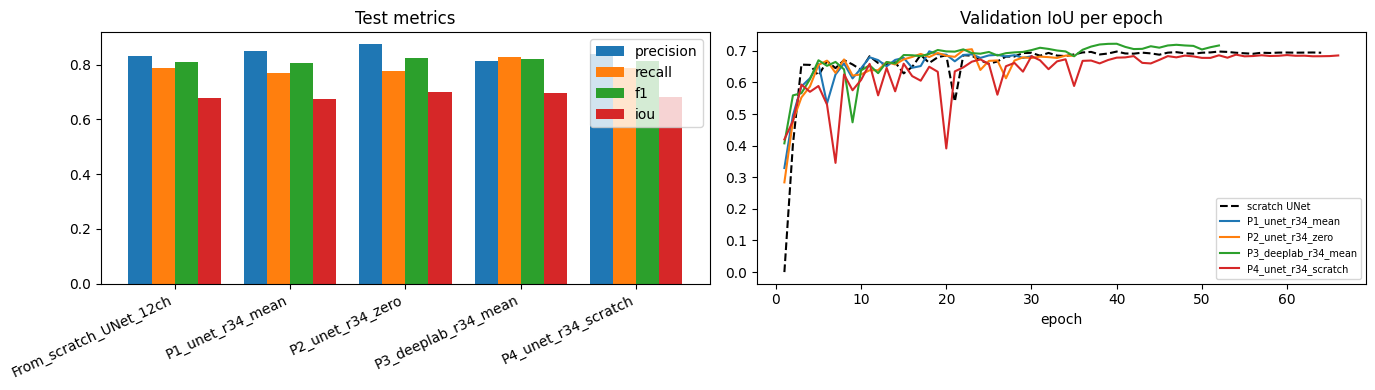

In [25]:
scratch = res[res.experiment == 'E1_baseline_12ch'].copy()
scratch['experiment'] = 'From_scratch_UNet_12ch'
cmp = pd.concat([scratch, pd.DataFrame(p_results)], ignore_index=True)
cols = ['experiment', 'precision', 'recall', 'f1', 'iou', 'best_val_iou', 'thr', 'epochs_run']
display(cmp[cols].round(4))
cmp[cols].round(4).to_csv('week2_comparison.csv', index=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(cmp)); wd = 0.2
for i, m in enumerate(['precision', 'recall', 'f1', 'iou']):
    ax[0].bar(x + (i - 1.5) * wd, cmp[m], wd, label=m)
ax[0].set_xticks(x); ax[0].set_xticklabels(cmp.experiment, rotation=25, ha='right')
ax[0].set_title('Test metrics'); ax[0].legend()

ax[1].plot(histories['E1_baseline_12ch'].epoch, histories['E1_baseline_12ch'].iou,
           label='scratch UNet', ls='--', c='k')
for n, h in p_hist.items():
    ax[1].plot(h.epoch, h.iou, label=n)
ax[1].set_title('Validation IoU per epoch'); ax[1].set_xlabel('epoch'); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

best pretrained (by val IoU): P3_deeplab_r34_mean


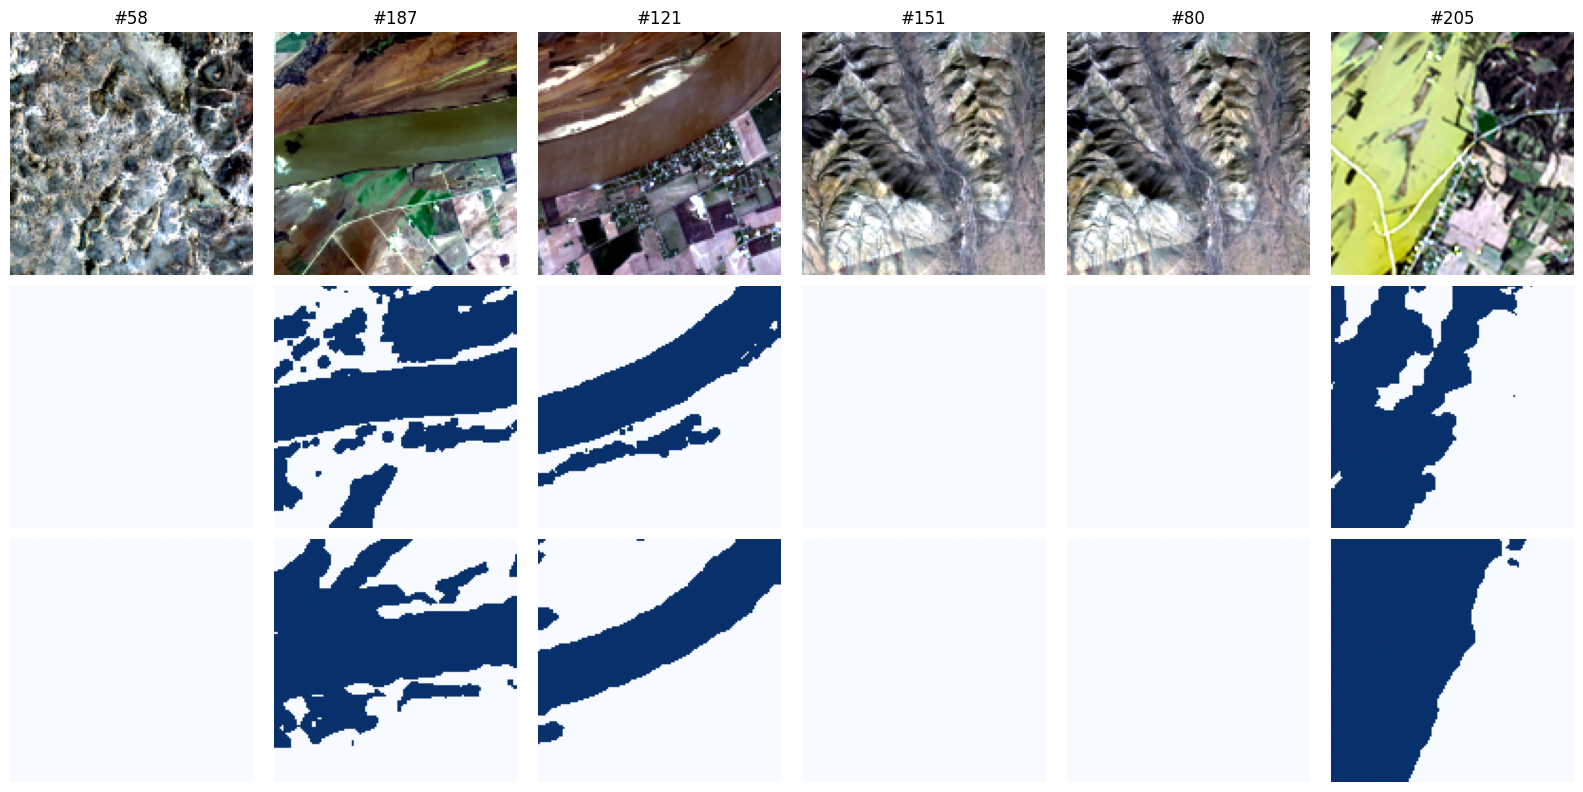

In [24]:
# Pick the best pretrained model by validation IoU (not test) to avoid selection bias
best_p = max(p_results, key=lambda r: r['best_val_iou'])['experiment']
print('best pretrained (by val IoU):', best_p)

pr = predict_probs(p_models[best_p], torch.from_numpy(np.ascontiguousarray(X_norm[te_idx][:, chans])))
pr = (pr.squeeze(1).numpy() > p_thr[best_p])

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for j, k in enumerate(np.random.RandomState(1).choice(len(te_idx), 6, replace=False)):
    i = te_idx[k]
    axes[0, j].imshow(rgb(X[i]));          axes[0, j].set_title(f'#{i}'); axes[0, j].axis('off')
    axes[1, j].imshow(Y[i], cmap='Blues'); axes[1, j].axis('off')
    axes[2, j].imshow(pr[k], cmap='Blues'); axes[2, j].axis('off')
axes[0, 0].set_ylabel('RGB'); axes[1, 0].set_ylabel('Ground truth'); axes[2, 0].set_ylabel('Prediction')
plt.tight_layout(); plt.show()